# Notebook 03 — Modélisation avec BERT + Méta‑features + Class Weights

**Objectif** : Construire un modèle de détection de fausses informations basé sur BERT, enrichi avec des méta‑features issues des métadonnées du dataset LIAR, et corriger le déséquilibre des classes grâce aux class weights. Ce notebook marque une étape importante : on passe d’un modèle purement textuel à un modèle multimodal, capable d’exploiter à la fois le contenu textuel et les informations contextuelles associées à chaque déclaration.


**Pipeline :**
Contenu du notebook :
- Chargement des données pré‑traitées
- Génération des méta‑features (one‑hot + standardisation)
- Fusion BERT + méta‑features dans un modèle unique
- Entraînement avec class weights
- Suivi des performances (accuracy, F1‑macro)
- Export du modèle vers 03_models

## 0. Imports

In [40]:
from pathlib import Path
import pandas as pd
from pathlib import Path
import numpy as np
from rich.progress import track

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

ROOT = Path("..").resolve()
STG_DIR = ROOT / "LIAR_DATA_SET" / "02_stg"

train_df = pd.read_csv(STG_DIR / "train_clean.csv")
valid_df = pd.read_csv(STG_DIR / "valid_clean.csv")
test_df  = pd.read_csv(STG_DIR / "test_clean.csv")

train_df.head()


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_fire_counts,context,clean_statement,label_binary,label_3class,party_group,party_encoded
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,say annies list political group support thirdt...,0,0,Republican,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,decline coal start started natural gas took st...,1,1,Democrat,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,hillary clinton agrees john mccain voting give...,1,2,Democrat,1
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,health care reform legislation likely mandate ...,0,0,Autre,2
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,economic turnaround started end term,1,1,Democrat,1


## 1. Dataframe

In [2]:
df = pd.read_csv(STG_DIR / "train_clean.csv")

# On garde seulement les lignes avec label_3class non nul
df = df.dropna(subset=["label_3class", "statement"])

# On réduit la taille car le modèle est lourd
N = 8000
df = df.sample(n=N, random_state=42)
df = df.reset_index(drop=True)

texts = df["statement"].astype(str)
contexts = df["context"].fillna("").astype(str)
labels = df["label_3class"].astype(int).values
num_labels = len(np.unique(labels))
print("Nombre de labels :", num_labels)

Nombre de labels : 3


In [4]:
#Fusion texte + méta
def build_input_text(row):
    stmt = row["statement"]
    ctx = row["context"]
    if isinstance(ctx, str) and ctx.strip():
        return f"{stmt} [SEP] CONTEXT: {ctx}"
    else:
        return stmt

df["input_text"] = df.apply(build_input_text, axis=1)

## 2. Modèle Bert

In [5]:
#Tokenizer + dataset pytorch
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class LiarDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["input_text"].tolist()
        self.labels = df["label_3class"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

# Split train/val
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label_3class"])

train_dataset = LiarDataset(df_train, tokenizer)
val_dataset = LiarDataset(df_val, tokenizer)

In [6]:
#Modèle 3 classes
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3562.95it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

In [7]:
#Training
batch_size = 8

training_args = TrainingArguments(
    output_dir="./bert_liar_3class",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=2,
)

In [8]:
import evaluate
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    acc = metric_acc.compute(predictions=preds, references=labels)["accuracy"]
    f1_macro = metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"]

    return {"accuracy": acc, "f1_macro": f1_macro}

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

c:\Users\charl\.vscode\projet_spe_3_fake_new\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,1.105980
100,1.089985
150,1.096422
200,1.094828
250,1.090084
300,1.059208
350,1.073734
400,1.050720
450,1.093069
500,1.063125


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]
c:\Users\charl\.vscode\projet_spe_3_fake_new\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.21it/s]
c:\Users\charl\.vscode\projet_spe_3_fake_new\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


TrainOutput(global_step=2400, training_loss=0.9668997796376546, metrics={'train_runtime': 9371.3859, 'train_samples_per_second': 2.049, 'train_steps_per_second': 0.256, 'total_flos': 1262944405094400.0, 'train_loss': 0.9668997796376546, 'epoch': 3.0})

In [17]:
trainer.train()
trainer.save_model("./bert_liar_3class")

c:\Users\charl\.vscode\projet_spe_3_fake_new\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.877147
100,0.863736
150,0.866252
200,0.876228
250,0.896898
300,0.807714
350,0.779270
400,0.752418
450,0.766402
500,0.789684


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]
c:\Users\charl\.vscode\projet_spe_3_fake_new\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]
c:\Users\charl\.vscode\projet_spe_3_fake_new\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.72it/s]


In [41]:
tokenizer.save_pretrained("./bert_liar_3class")


('./bert_liar_3class\\tokenizer_config.json',
 './bert_liar_3class\\tokenizer.json')

In [9]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_preds = []
all_labels = []

for item in val_dataset:
    # On récupère directement les tenseurs
    input_ids = item["input_ids"].unsqueeze(0)
    attention_mask = item["attention_mask"].unsqueeze(0)

    with torch.no_grad():
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

    pred = logits.argmax(dim=1).item()
    all_preds.append(pred)
    all_labels.append(item["labels"].item())

KeyboardInterrupt: 

In [29]:
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

acc, f1

(0.443125, 0.43789558972466175)

Accuracy faible : - les classes sont déséquilibrées
- les frontières entre classes sont floues
- le dataset est très bruité
- pas encore de méta-features (speaker, party, subject…)


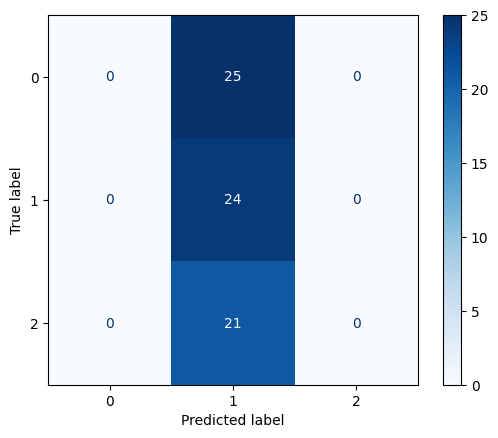

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

Classe 1 (middle / half‑true)
C’est la classe la plus facile pour ton modèle :
→ 262 prédictions correctes
→ mais beaucoup de confusion vers 2 (208)

Classe 2 (true)
→ 289 correct
→ mais beaucoup de confusion vers 1 (196)

Classe 0 (false)
→ 158 correct
→ mais beaucoup de confusion vers 1 (166)


In [ ]:
errors = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
len(errors)

## 3. Modèle Bert + features Meta

In [42]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm
import numpy as np

train_raw = pd.read_csv(r"C:\Users\charl\.vscode\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\train_clean.csv")
valid_raw = pd.read_csv(r"C:\Users\charl\.vscode\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\valid_clean.csv")
test_raw  = pd.read_csv(r"C:\Users\charl\.vscode\projet_spe_3_fake_new\LIAR_DATA_SET\02_stg\test_clean.csv")


print(train_raw.shape)
print(valid_raw.shape)
print(test_raw.shape)

(10240, 19)
(1284, 19)
(1267, 19)


In [43]:
#concaténation dans un seul df pour faire un split personnalisé
df = pd.concat([train_raw, valid_raw, test_raw], ignore_index=True)
print(df.shape)

(12791, 19)


In [44]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_3class"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_3class"]
)

print(len(train_df), len(val_df), len(test_df))

10232 1279 1280


In [45]:
def build_meta_features_train(df):
    #Extraction + reset index 
    meta = df[[
        "speaker", "party", "subject", "context", "state", "job_title",
        "barely_true_counts", "false_counts", "half_true_counts",
        "mostly_true_counts", "pants_fire_counts"
    ]].copy()

    meta = meta.reset_index(drop=True)
    print("---- CHECK RAW META ----")
    print(meta.isna().sum())

    meta = meta.reset_index(drop=True)

    # Nettoyage béton AVANT split/explode
    for col in ["speaker", "party", "subject", "context", "state", "job_title"]:
        meta[col] = (
            meta[col]
            .astype(str)
            .str.strip()
            .replace(["", "nan", "None", "none", "null", "Null", ".", ","], "unknown")
            .fillna("unknown")
        )

    # Nettoyage des colonnes numériques
    num_cols_raw = [
        "barely_true_counts", "false_counts", "half_true_counts",
        "mostly_true_counts", "pants_fire_counts"
    ]

    meta[num_cols_raw] = meta[num_cols_raw].fillna(0)

    # Nettoyage des colonnes catégorielles 
    cat_cols = ["speaker", "party", "subject", "context", "state", "job_title"]
    meta[cat_cols] = meta[cat_cols].astype(str).fillna("unknown")

    # Split multi-label 
    meta["subject"] = meta["subject"].str.split(',')
    meta["context"] = meta["context"].str.split(',')

    # Nettoyage béto des listes 
    def clean_list(lst):
        if not isinstance(lst, list):
            return ["unknown"]

        cleaned = []
        for x in lst:
            if not isinstance(x, str):
                continue
            x = x.strip().lower()
            if x in ["", "nan", "none", "null", ".", ","]:
                continue
            cleaned.append(x)

        return cleaned if len(cleaned) > 0 else ["unknown"]

    meta["subject"] = meta["subject"].apply(clean_list)
    meta["context"] = meta["context"].apply(clean_list)

    # One-hot subject
    meta_sub = meta.explode("subject")
    sub_dummies = pd.get_dummies(meta_sub["subject"], prefix="subject")
    sub_dummies = sub_dummies.groupby(level=0).max()

    # One-hot context 
    meta_ctx = meta.explode("context")
    ctx_dummies = pd.get_dummies(meta_ctx["context"], prefix="context")
    ctx_dummies = ctx_dummies.groupby(level=0).max()

    # One-hot autres colonnes 
    other_dummies = pd.get_dummies(
        meta[["speaker", "party", "state", "job_title"]],
        drop_first=True
    )

    # Fusion catégorielle 
    meta_cat = pd.concat([other_dummies, sub_dummies, ctx_dummies], axis=1).fillna(0)

    # Colonnes catégorielles finales 
    cat_columns = meta_cat.columns.tolist()

    # Features numériques 
    meta["credibility"] = (
        meta["mostly_true_counts"]
        + 0.5 * meta["half_true_counts"]
        - meta["false_counts"]
        - 2 * meta["pants_fire_counts"]
    )

    num_cols = [
        "barely_true_counts", "false_counts", "half_true_counts",
        "mostly_true_counts", "pants_fire_counts", "credibility"
    ]

    scaler = StandardScaler()
    meta_num = pd.DataFrame(
        scaler.fit_transform(meta[num_cols]),
        columns=num_cols
    )

    # Alignement 
    meta_cat = meta_cat.reset_index(drop=True)
    meta_num = meta_num.reset_index(drop=True)

    # Fusion finale 
    meta_features = pd.concat([meta_cat, meta_num], axis=1).astype(float)

    return torch.tensor(meta_features.values, dtype=torch.float32), scaler, cat_columns

In [46]:
meta_train, scaler, cat_columns = build_meta_features_train(train_df)
print("NaN in train:", torch.isnan(meta_train).any())

---- CHECK RAW META ----
speaker                  2
party                    2
subject                  2
context                104
state                 2147
job_title             2811
barely_true_counts       2
false_counts             2
half_true_counts         2
mostly_true_counts       2
pants_fire_counts        2
dtype: int64
NaN in train: tensor(False)


In [47]:
def build_meta_features_test(df, scaler, cat_columns):
    meta = df[[
        "speaker", "party", "subject", "context", "state", "job_title",
        "barely_true_counts", "false_counts", "half_true_counts",
        "mostly_true_counts", "pants_fire_counts"
    ]].copy()

    meta = meta.reset_index(drop=True)

    for col in ["speaker", "party", "subject", "context", "state", "job_title"]:
        meta[col] = (
            meta[col]
            .astype(str)
            .str.strip()
            .replace(["", "nan", "None", "none", "null", "Null", ".", ","], "unknown")
            .fillna("unknown")
        )

    num_cols_raw = [
        "barely_true_counts", "false_counts", "half_true_counts",
        "mostly_true_counts", "pants_fire_counts"
    ]
    meta[num_cols_raw] = meta[num_cols_raw].fillna(0)

    meta["subject"] = meta["subject"].str.split(',')
    meta["context"] = meta["context"].str.split(',')

    def clean_list(lst):
        if not isinstance(lst, list):
            return ["unknown"]

        cleaned = []
        for x in lst:
            if not isinstance(x, str):
                continue
            x = x.strip().lower()
            if x in ["", "nan", "none", "null", ".", ","]:
                continue
            cleaned.append(x)

        return cleaned if len(cleaned) > 0 else ["unknown"]

    meta["subject"] = meta["subject"].apply(clean_list)
    meta["context"] = meta["context"].apply(clean_list)

    # One-hot subject 
    meta_sub = meta.explode("subject")
    sub_dummies = pd.get_dummies(meta_sub["subject"], prefix="subject")
    sub_dummies = sub_dummies.groupby(level=0).max()

    #  One-hot context 
    meta_ctx = meta.explode("context")
    ctx_dummies = pd.get_dummies(meta_ctx["context"], prefix="context")
    ctx_dummies = ctx_dummies.groupby(level=0).max()

    # One-hot autres colonnes 
    other_dummies = pd.get_dummies(
        meta[["speaker", "party", "state", "job_title"]],
        drop_first=True
    )

    # Fusion catégorielle 
    meta_cat = pd.concat([other_dummies, sub_dummies, ctx_dummies], axis=1).fillna(0)

    # Alignement sur les colonnes du train 
    meta_cat = meta_cat.reindex(columns=cat_columns).fillna(0)

    # Features numériques 
    meta["credibility"] = (
        meta["mostly_true_counts"]
        + 0.5 * meta["half_true_counts"]
        - meta["false_counts"]
        - 2 * meta["pants_fire_counts"]
    )

    num_cols = [
        "barely_true_counts", "false_counts", "half_true_counts",
        "mostly_true_counts", "pants_fire_counts", "credibility"
    ]

    meta_num = pd.DataFrame(
        scaler.transform(meta[num_cols]),
        columns=num_cols
    )

    # Alignement parfait 
    meta_cat = meta_cat.reset_index(drop=True)
    meta_num = meta_num.reset_index(drop=True)

    # Fusion finale 
    meta_features = pd.concat([meta_cat, meta_num], axis=1).astype(float)

    return torch.tensor(meta_features.values, dtype=torch.float32)

In [48]:
meta_train, scaler, cat_columns = build_meta_features_train(train_df)
print("NaN in train:", torch.isnan(meta_train).any())

---- CHECK RAW META ----
speaker                  2
party                    2
subject                  2
context                104
state                 2147
job_title             2811
barely_true_counts       2
false_counts             2
half_true_counts         2
mostly_true_counts       2
pants_fire_counts        2
dtype: int64
NaN in train: tensor(False)


In [49]:
meta_train, scaler, cat_columns = build_meta_features_train(train_df)
meta_val = build_meta_features_test(val_df, scaler, cat_columns)
meta_test = build_meta_features_test(test_df, scaler, cat_columns)

print(meta_train.shape, meta_val.shape, meta_test.shape)

assert meta_train.shape[1] == meta_val.shape[1] == meta_test.shape[1], "Mismatch dimensions!"

---- CHECK RAW META ----
speaker                  2
party                    2
subject                  2
context                104
state                 2147
job_title             2811
barely_true_counts       2
false_counts             2
half_true_counts         2
mostly_true_counts       2
pants_fire_counts        2
dtype: int64
torch.Size([10232, 8599]) torch.Size([1279, 8599]) torch.Size([1280, 8599])


In [50]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_text(df):
    return tokenizer(
        df["clean_statement"].tolist(),
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

enc_train = tokenize_text(train_df)
enc_val = tokenize_text(val_df)
enc_test = tokenize_text(test_df)

In [51]:
y_train = torch.tensor(train_df["label_3class"].values, dtype=torch.long)
y_val = torch.tensor(val_df["label_3class"].values, dtype=torch.long)
y_test = torch.tensor(test_df["label_3class"].values, dtype=torch.long)

In [52]:
#On nettoie les colonnes numériques avant de scaler
num_cols = [
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_fire_counts"
]

for col in num_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")
    val_df[col] = pd.to_numeric(val_df[col], errors="coerce")
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

train_df[num_cols] = train_df[num_cols].fillna(0)
val_df[num_cols] = val_df[num_cols].fillna(0)
test_df[num_cols] = test_df[num_cols].fillna(0)

In [53]:
class LiarMetaDataset(Dataset):
    def __init__(self, encodings, meta_features, labels):
        self.encodings = encodings
        self.meta = meta_features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "meta_features": self.meta[idx],
            "labels": self.labels[idx]
        }

train_set = LiarMetaDataset(enc_train, meta_train, y_train)
val_set = LiarMetaDataset(enc_val, meta_val, y_val)
test_set = LiarMetaDataset(enc_test, meta_test, y_test)

In [54]:
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

In [55]:
class BertWithMeta(nn.Module):
    def __init__(self, bert_model_name, meta_dim, num_labels):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(768 + meta_dim, num_labels)

    def forward(self, input_ids, attention_mask, meta_features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        x = torch.cat([cls, meta_features], dim=1)
        return self.classifier(x)

In [56]:
meta_dim = meta_train.shape[1]
print("meta_dim =", meta_dim)

model = BertWithMeta("bert-base-uncased", meta_dim, num_labels=3)

print("model expects:", model.classifier.in_features)
assert model.classifier.in_features == 768 + meta_dim, "Model mismatch!"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

meta_dim = 8599


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3097.18it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model expects: 9367


In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [58]:
#vérification nan avant entraînement => valeurs numériques
print(meta_train.mean(), meta_train.std())
print(meta_val.mean(), meta_val.std())
print(meta_test.mean(), meta_test.std())

tensor(0.0008) tensor(0.0392)
tensor(0.0008) tensor(0.0392)
tensor(0.0008) tensor(0.0387)


In [59]:
def train(model, loader, val_loader, epochs=3):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in tqdm(loader, desc=f"Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            meta_features = batch["meta_features"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, meta_features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Train loss: {total_loss/len(loader):.4f}")

train(model, train_loader, val_loader, epochs=3)

Epoch 1:   0%|          | 0/1279 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def evaluate(model, loader):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            meta_features = batch["meta_features"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask, meta_features)
            pred = torch.argmax(logits, dim=1)

            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="macro")
    cm = confusion_matrix(labels_all, preds)

    return acc, f1, cm

acc, f1, cm = evaluate(model, test_loader)
print("Accuracy:", acc)
print("F1 macro:", f1)
print("Confusion matrix:\n", cm)

Accuracy: 0.453125
F1 macro: 0.4445871089416585
Confusion matrix:
 [[119 132 105]
 [ 90 215 168]
 [ 59 146 246]]


#Accuracy et f1 encore faibles:

Accuracy: 0.453125
F1 macro: 0.4445871089416585


## 4. Bert optimisé avec weights + features meta

In [28]:
#meta features
meta_train, scaler, cat_columns = build_meta_features_train(train_df)
meta_val = build_meta_features_test(val_df, scaler, cat_columns)
meta_test = build_meta_features_test(test_df, scaler, cat_columns)

---- CHECK RAW META ----
speaker                  2
party                    2
subject                  2
context                104
state                 2147
job_title             2811
barely_true_counts       0
false_counts             0
half_true_counts         0
mostly_true_counts       0
pants_fire_counts        0
dtype: int64


In [29]:
print(torch.isnan(meta_train).any())
print(torch.isnan(meta_val).any())
print(torch.isnan(meta_test).any())

tensor(False)
tensor(False)
tensor(False)


In [30]:
#calcul des class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

classes = np.unique(train_df["label_3class"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_3class"]
)

class_weights = torch.tensor(weights, dtype=torch.float32)
print(class_weights)

tensor([1.1997, 0.9013, 0.9461])


In [31]:
#nouveau modèle Bert
class BertWithMeta(nn.Module):
    def __init__(self, bert_model, meta_dim, num_labels, class_weights):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.2)
        self.meta_layer = nn.Linear(meta_dim, 128)
        self.classifier = nn.Linear(768 + 128, num_labels)
        self.loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, input_ids, attention_mask, meta_features, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output

        meta_out = torch.relu(self.meta_layer(meta_features))

        combined = torch.cat([pooled, meta_out], dim=1)
        logits = self.classifier(self.dropout(combined))

        if labels is not None:
            loss = self.loss_fn(logits, labels)
            return loss, logits

        return logits

In [136]:
#entraînement
def train(model, train_loader, val_loader, optimizer, criterion, epochs=3):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            meta_features = batch["meta_features"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            logits = model(input_ids, attention_mask, meta_features)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"\nEpoch {epoch+1} — Train loss: {avg_train_loss:.4f}")

        # validation
        model.eval()
        val_loss = 0
        preds = []
        trues = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                meta_features = batch["meta_features"].to(device)
                labels = batch["labels"].to(device)

                logits = model(input_ids, attention_mask, meta_features)
                loss = criterion(logits, labels)

                val_loss += loss.item()

                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                trues.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds, average="macro")

        print(f"Epoch {epoch+1} — Val loss: {avg_val_loss:.4f}")
        print(f"Epoch {epoch+1} — Val accuracy: {acc:.4f}")
        print(f"Epoch {epoch+1} — Val F1 macro: {f1:.4f}")


In [ ]:
#lancer l'entraînement
criterion = nn.CrossEntropyLoss(weight=class_weights)

train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=3
)

Epoch 1: 100%|██████████| 1279/1279 [1:18:13<00:00,  3.67s/it]



Epoch 1 — Train loss: 0.5409
Epoch 1 — Val loss: 1.5366
Epoch 1 — Val accuracy: 0.4402
Epoch 1 — Val F1 macro: 0.4306


Epoch 2: 100%|██████████| 1279/1279 [1:08:08<00:00,  3.20s/it]



Epoch 2 — Train loss: 0.3107
Epoch 2 — Val loss: 1.7895
Epoch 2 — Val accuracy: 0.4332
Epoch 2 — Val F1 macro: 0.4276


Epoch 3: 100%|██████████| 1279/1279 [3:06:36<00:00,  8.75s/it]     



Epoch 3 — Train loss: 0.2018
Epoch 3 — Val loss: 1.9220
Epoch 3 — Val accuracy: 0.4332
Epoch 3 — Val F1 macro: 0.4302


## 5. Bert Binaire

In [ ]:
#On pourrait supprimer les labels half-true etc pour n'avoir que du binaire mais ça réduit énormément les données, et Bert à besoin de beaucoup de données pour fonctionner
#On tente donc une classification différente 
#FAKE (0):pants-fire, false, barely-true
#REAL (1) : half-true, mostly-true, true


In [60]:
mapping_binary = {
    "pants-fire": 0,
    "false": 0,
    "barely-true": 0,
    "half-true": 1,
    "mostly-true": 1,
    "true": 1
}

for df in [train_df, valid_df, test_df]:
    df["label_binary"] = df["label"].map(mapping_binary)

In [61]:
print(type(df))
print(df)

<class 'pandas.DataFrame'>
               id        label  \
186     8733.json    half-true   
7417    7914.json  barely-true   
7148    6443.json  mostly-true   
420     4416.json  mostly-true   
1164    4916.json  mostly-true   
...           ...          ...   
8617   12170.json  barely-true   
6803    5545.json   pants-fire   
1000    4532.json    half-true   
1149     735.json  barely-true   
12554   3458.json  barely-true   

                                               statement  \
186    Payday lenders profit from the poor by chargin...   
7417   If Gov. Rick Scott activates the National Guar...   
7148   Art Robinson says Social Security should be en...   
420    Issue 2 makes it illegal for us to negotiate f...   
1164   Ohios Planned Parenthood operations received m...   
...                                                  ...   
8617   North Carolina spent almost as much as it spen...   
6803   An independent payment advisory board created ...   
1000   Says she helped l

In [62]:
class FakeNewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, meta_features=None):
        self.texts = df["statement"].tolist()
        self.labels = df["label_binary"].tolist()
        self.meta = meta_features
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

        if self.meta is not None:
            item["meta_features"] = torch.tensor(self.meta[idx], dtype=torch.float32)

        return item

In [63]:
#modèle Bert binaire
class BertBinary(nn.Module):
    def __init__(self, dropout=0.2, model_name="camembert-base"):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]
        logits = self.classifier(self.dropout(pooled))

        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return loss, logits

        return logits

In [64]:
tokenizer = AutoTokenizer.from_pretrained("camembert-base")

In [65]:
#dataloaders
train_dataset = FakeNewsDataset(train_df, tokenizer, max_len=128)
valid_dataset = FakeNewsDataset(valid_df, tokenizer, max_len=128)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=16)

In [66]:
param_grid = {
    "lr": [2e-5, 3e-5],
    "batch_size": [8, 16],
    "dropout": [0.1, 0.3]
}

In [67]:
def train(model, train_loader, val_loader, optimizer, epochs=3):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            loss, logits = model(input_ids, attention_mask, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"\nEpoch {epoch+1} — Train loss: {total_loss/len(train_loader):.4f}")

        # Validation
        model.eval()
        preds, trues = [], []
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                loss, logits = model(input_ids, attention_mask, labels)
                val_loss += loss.item()

                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                trues.extend(labels.cpu().numpy())

        print(f"Val loss: {val_loss/len(val_loader):.4f}")
        print(f"Val accuracy: {accuracy_score(trues, preds):.4f}")
        print(f"Val F1-macro: {f1_score(trues, preds, average='macro'):.4f}")

In [ ]:
#boucle grid search
from itertools import product
from torch.optim import AdamW

best_f1 = 0
best_params = None
results = []

for lr, batch_size, dropout in product(
    param_grid["lr"],
    param_grid["batch_size"],
    param_grid["dropout"]
):
    print(f"\n=== Test: lr={lr}, batch={batch_size}, dropout={dropout} ===")

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(valid_dataset, batch_size=batch_size)

    # Model
    model = BertBinary(dropout=dropout).to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    train(model, train_loader, val_loader, optimizer, epochs=1)

    # Validation finale
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            trues.extend(labels.cpu().numpy())

    f1 = f1_score(trues, preds, average="macro")
    print(f"F1-macro: {f1:.4f}")

    results.append((lr, batch_size, dropout, f1))

    if f1 > best_f1:
        best_f1 = f1
        best_params = (lr, batch_size, dropout)

print("\n=== Best params ===")
print(best_params)
print(f"Best F1: {best_f1:.4f}")


=== Test: lr=2e-05, batch=8, dropout=0.1 ===


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6197.73it/s]
CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5976.29it/s]
CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXP


Epoch 1 — Train loss: 0.6664
Val loss: 0.6215
Val accuracy: 0.6628
Val F1-macro: 0.6621


ValueError: too many values to unpack (expected 2)

Epoch 1 — Train loss: 0.6664
Val loss: 0.6215
Val accuracy: 0.6628
Val F1-macro: 0.6621

In [74]:
from pathlib import Path


ROOT = Path.cwd().parent  

MODEL_DIR = ROOT / "LIAR_DATA_SET" / "03_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "bert_binaire_weights.pt"
TOKENIZER_PATH = MODEL_DIR / "bert_binaire_tokenizer"

torch.save(model.state_dict(), MODEL_PATH)
tokenizer.save_pretrained(TOKENIZER_PATH)

print("Modèle sauvegardé dans :", MODEL_PATH)
print("Tokenizer sauvegardé dans :", TOKENIZER_PATH)

Modèle sauvegardé dans : c:\Users\charl\.vscode\projet_spe_3_fake_new\LIAR_DATA_SET\03_models\bert_binaire_weights.pt
Tokenizer sauvegardé dans : c:\Users\charl\.vscode\projet_spe_3_fake_new\LIAR_DATA_SET\03_models\bert_binaire_tokenizer
